# Parkinson Sensorimotor EEG Analysis to Understand Gait Disturbance in Parkinson’s Disease Patients

## Question

Is the frequency of EEG channels around the sensorimotor cortex diIerent between resting
and walking in both Parkinsonian and control groups, and is long-term functional
coherence across regions weaker in the Parkinson group compared to the control group?

## Data Description

The original dataset comprises 64-channel electroencephalogram (EEG) recordings from patients
with Parkinson’s disease (PD; n = 116) and healthy controls (HC; n = 28). The study
recruited subjects aged 40-90 and included only mild Parkinson's disease patients (Hoehn
& Yahr scale < 4 & MoCA > 20) who could walk independently. Subjects with a history of
brain surgery, head injury, stroke, or other major neurological disorders other than
Parkinson’s. During resting state recording (n = 144), subjects sat in a chair with their eyes
open for up to 4 minutes. During walking (n = 133), subjects walked on a treadmill with
handrail support for the same duration. There are demographic and clinical data, including
MoCA (Montreal Cognitive Assessment) and MDS-UPDRS (Movement Disorder Society
Unified Parkinson’s Disease Rating Scale). The dataset was acquired at the Neurology
Institute of Tel Aviv Sourasky Medical Center and is downloadable from the [OpenNeuro
database](doi:10.18112/openneuro.ds007526.v1.0.0).

### Propensity Score Matching
Propensity score matching (PSM) is performed to sample the dataset and remove effects of age, sex, and MoCA (cognition score). Cognition level differs between HC and PD groups, although only mild PD subjects are included. Still, EEG difference caused by impaired neural mechanism controling gait is the main focus, so cognitive impairment might be a covariate.

In [70]:
import pandas as pd
from utils import PropensityScoreMatching

df = pd.read_csv("data/ds007526/participants.tsv", sep="\t", na_values="n/a")
psm = PropensityScoreMatching(
        target_col="group",
        features=["age", "sex", "moca"],
        data_dir='./data/ds007526',
        required_tasks=['rest','walk']
        )
matched_df = psm.fit_match(df).reset_index(drop=True)
psm.summary()

  Propensity Score Matching Summary
  Reference (minority) : HC
  Matched  (majority)  : PD

                                Before        After
  --------------------------------------------------
  HC                                23           19
  PD                               108           19

  Covariate Balance (SMD < 0.1 = well-balanced)
  Feature                SMD Before   SMD After    p Before     p After
  --------------------------------------------------------------------
  age                        0.5060      0.1544      0.0160      0.6376 ✗
  sex                        0.4588      0.3198      0.0785      0.5164 ✗
  moca                       0.8930      0.2882      0.0000      0.3804 ✗


/Users/wjung/Library/CloudStorage/OneDrive-UCSF/Documents/PhD/ParkinsonTSA/utils/psm.py:284: UserWarning: Excluded 11 subject(s) missing one or more required task recordings ['rest', 'walk']: ['sub-001', 'sub-005', 'sub-016', 'sub-020', 'sub-025', 'sub-036', 'sub-043', 'sub-084', 'sub-100', 'sub-120', 'sub-126']
  return self.fit(df).match()
/Users/wjung/Library/CloudStorage/OneDrive-UCSF/Documents/PhD/ParkinsonTSA/utils/psm.py:284: UserWarning: Dropped 2 row(s) with missing feature values (133 → 131 rows).
  return self.fit(df).match()
/Users/wjung/Library/CloudStorage/OneDrive-UCSF/Documents/PhD/ParkinsonTSA/utils/psm.py:284: UserWarning: 4 minority subject(s) could not be matched (caliper too strict or insufficient majority subjects).
  return self.fit(df).match()


Below is the list of subjects used in this study.

In [72]:
matched_df
matched_df.to_csv('matched_df.csv', index = False)

### EEG Preprocessing

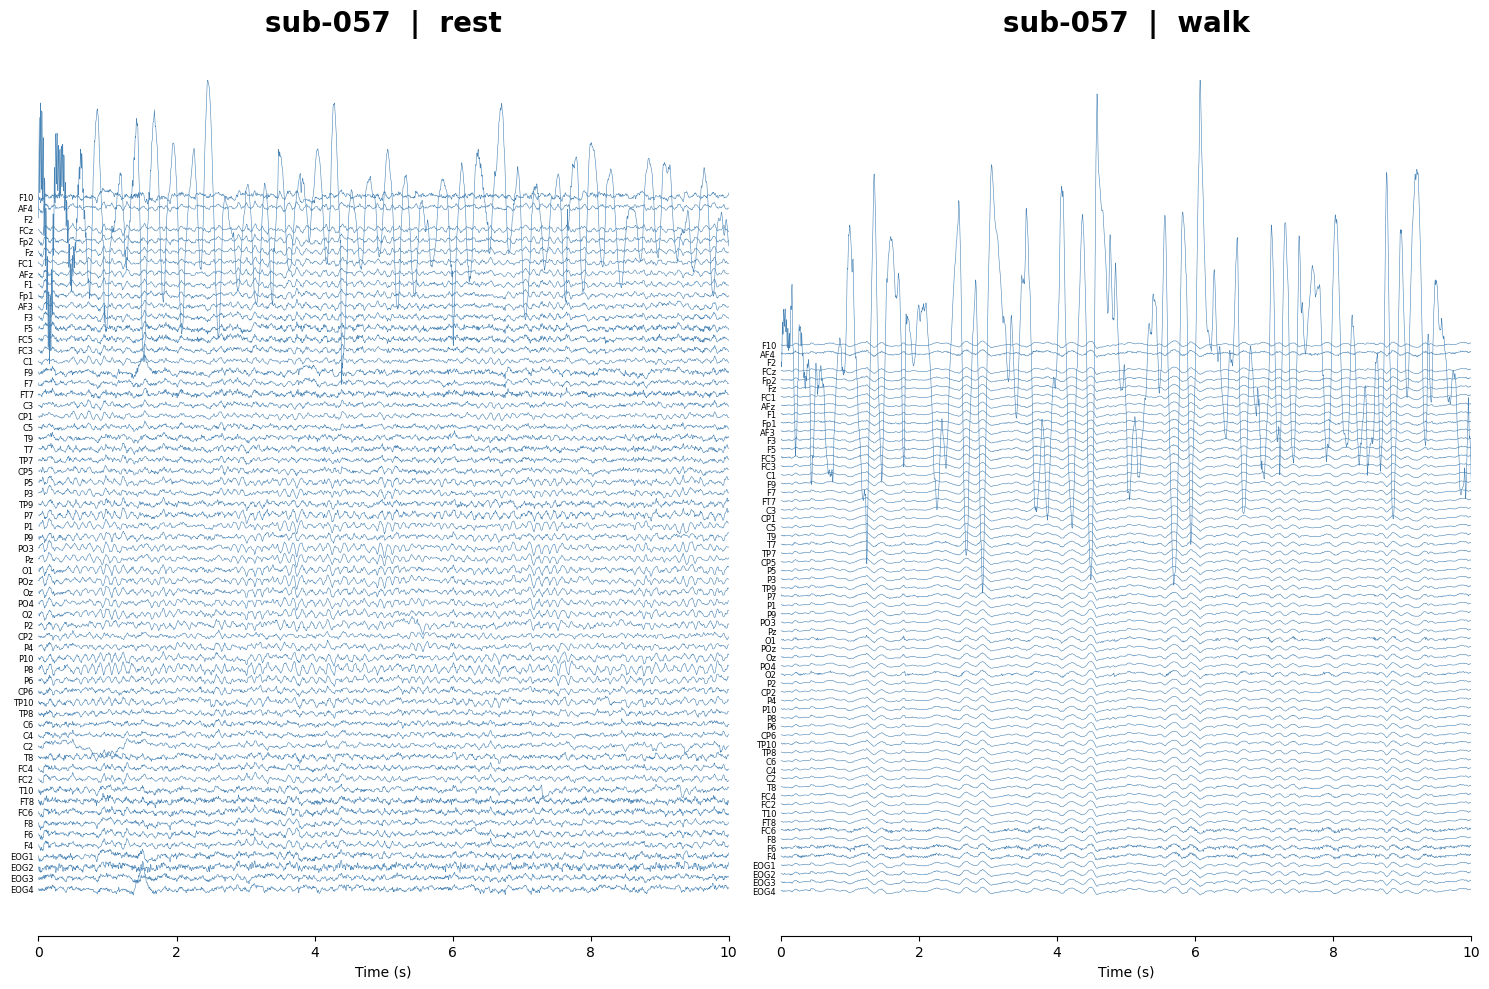

In [129]:
from utils.create_preprocessed_data import load_h5
from utils.plot import plot_eeg
import matplotlib.pyplot as plt

subid = '057'
fig, axs = plt.subplots(1, 2, figsize = (15, 10))
rest = load_h5(f"data_preprocessed/sub-{subid}_rest.h5")
walk = load_h5(f"data_preprocessed/sub-{subid}_walk.h5")

plot_eeg(da = rest, ax=axs[0])
plot_eeg(da = walk, ax=axs[1])
plt.tight_layout()
plt.show()

## Analysis 1: Power Spectral Analysis on Each EEG Channel and compare activities at resting or walking in HC vs PD

Apply power spectral analysis to all subjects’ recordings to identify which EEG channels show statistically different periodograms between sitting and walking states and determine the bandwidths of significance. Then apply a band-pass filter with the target bandwidth determined to reduce noise. Power spectral analysis decomposes the EEG into frequency components, revealing dominant rhythms associated with cognitive states.

For simplicity, we will focus on three bandwidths (theta: 4 - 8 Hz, frontal cortex; alpha: 8 - 12 Hz, parietal cortex; beta: 13 - 30 Hz, sensorimotor cortex) at channels on cortices known for exhibiting distinct signals during resting vs walking.

This is the list of the EEG channels that we're going to use & their approximate locations.

theta
bandwith: 4-8Hz
target channels: ['AFz', 'Fz', 'FCz', 'FC1', 'FC2']
alpha
bandwith: 8-12Hz
target channels: ['Pz', 'P1', 'P2', 'P3', 'P4', 'POz']
beta
bandwith: 13-30Hz
target channels: ['FCz', 'C1', 'C2', 'C3', 'C4', 'CP1', 'CP2']
Saved 2D plot to electrode_locations_2d.png


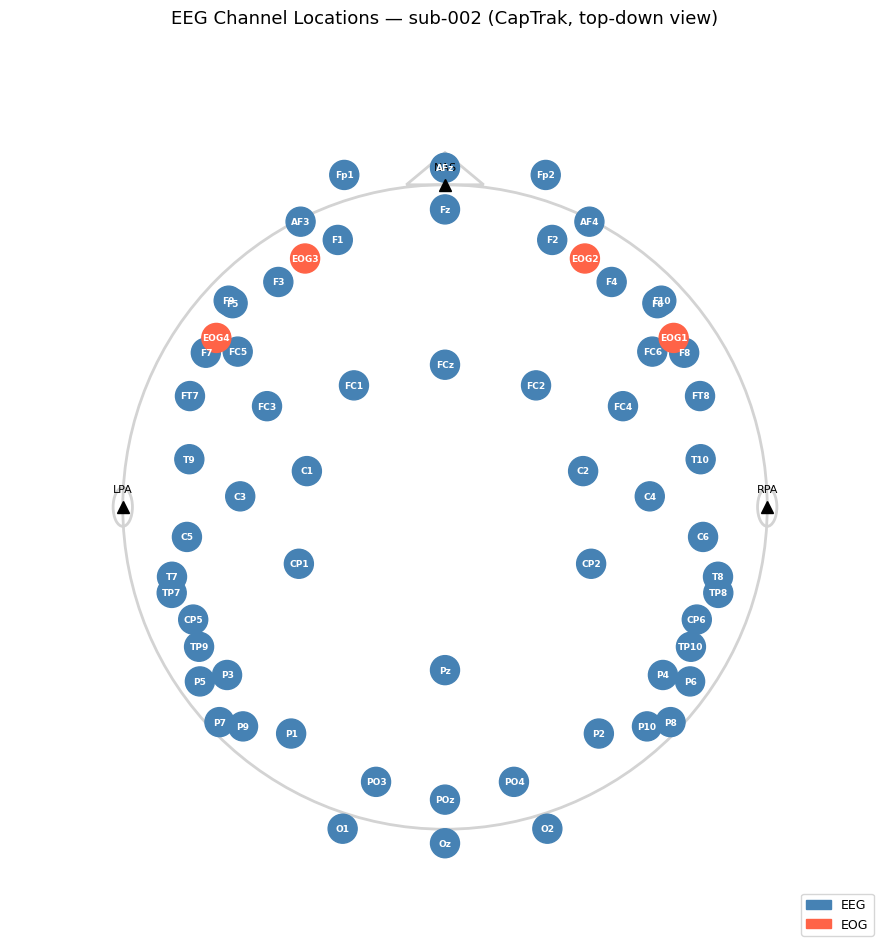

In [1]:
%matplotlib inline
from config import GROUP
from plot_electrode_locations import plot_2d, plot_3d

for key,value in GROUP.items():
    print(key)
    print('bandwith:', f"{value['band'][0]}-{value['band'][1]}Hz")
    print('target channels:', value['channel'])
plot_2d()

Let's first plot example periodograms and spectrograms of a PD subject.

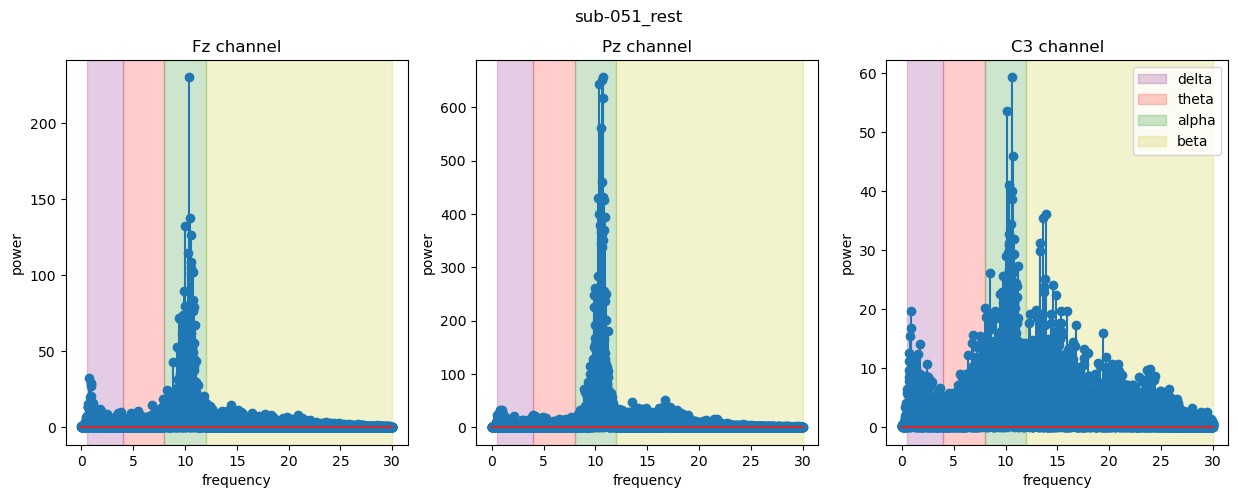

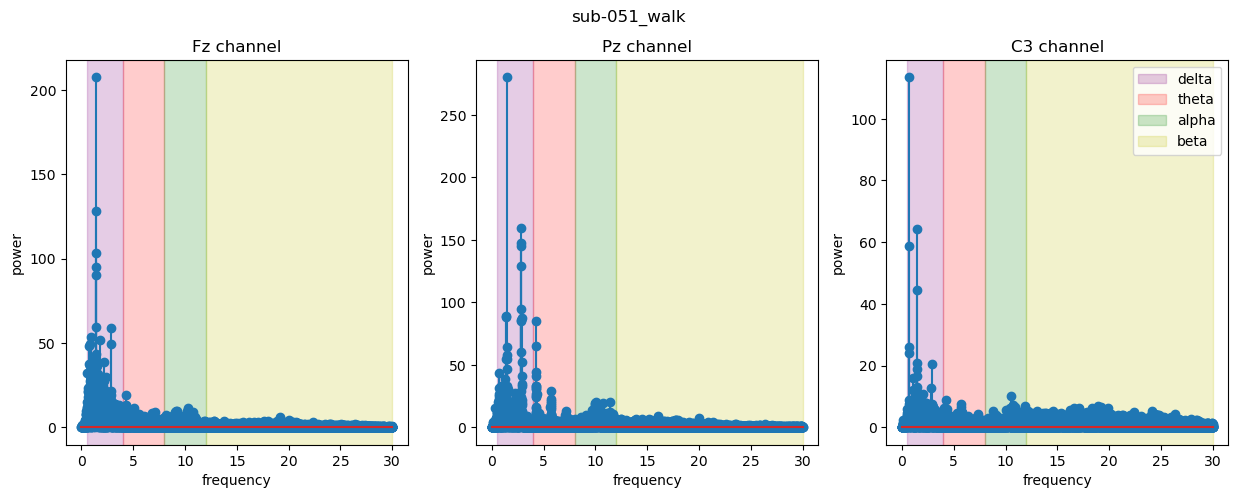

In [2]:
import numpy as np
from utils.create_preprocessed_data import load_h5
from scipy.signal import periodogram, spectrogram
import matplotlib.pyplot as plt

subject = 'sub-051' #PD subject
for task in ['rest','walk']:
    data = load_h5(f"data_preprocessed/{subject}_{task}.h5")
    channel_names = data.channel.values

    fig, axs = plt.subplots(1, 3, figsize = (15, 5))
    for idx, channelname in enumerate(['Fz','Pz','C3']): #example channels
        chan_idx = np.where(channel_names == channelname)[0][0]
        freqs, power = periodogram(data.values[chan_idx, :] *1e6, fs=data.sfreq)
        axs[idx].stem(freqs[freqs < 30], power[freqs < 30])
        axs[idx].set_xlabel('frequency')
        axs[idx].set_ylabel('power')
        axs[idx].set_title(f'{channelname} channel')
        axs[idx].axvspan(0.5, 4, color = 'purple', alpha = 0.2, label = 'delta')
        axs[idx].axvspan(4, 8, color = 'r', alpha = 0.2, label = 'theta')
        axs[idx].axvspan(8, 12, color = 'g', alpha = 0.2, label = 'alpha')
        axs[idx].axvspan(12, 30, color = 'y', alpha = 0.2, label = 'beta')
    axs[2].legend()
    plt.suptitle(f'{subject}_{task}')
    plt.show()


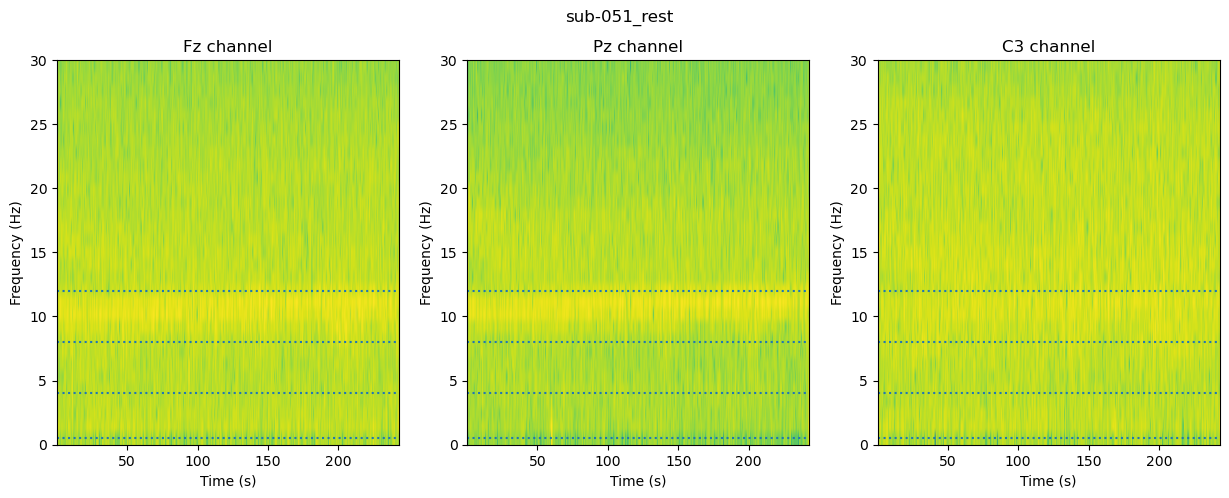

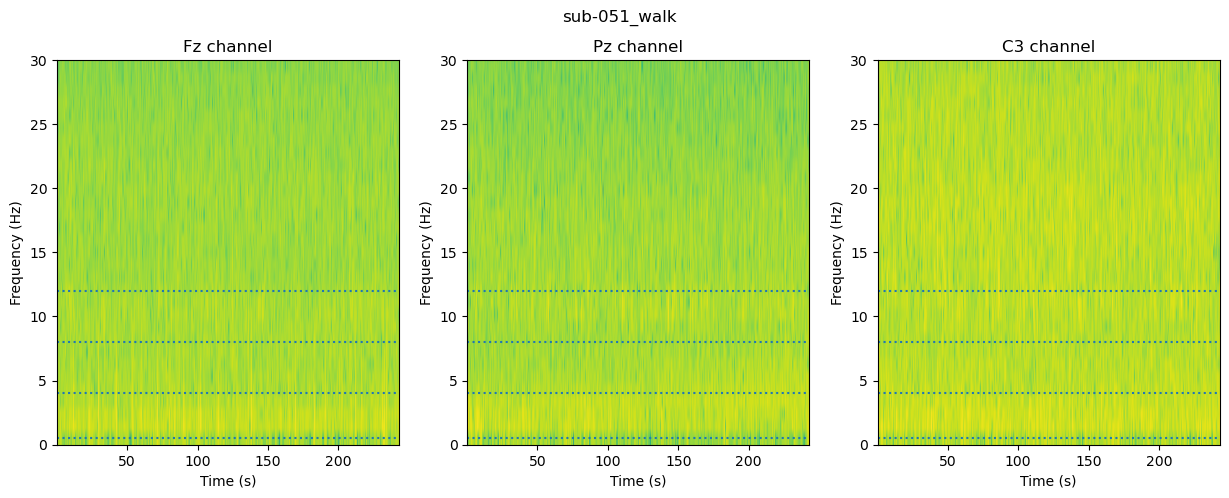

In [3]:
for task in ['rest','walk']:
    data = load_h5(f"data_preprocessed/{subject}_{task}.h5")
    channel_names = data.channel.values

    fig, axs = plt.subplots(1, 3, figsize = (15, 5))
    for idx, channelname in enumerate(['Fz','Pz','C3']): #example channels
        chan_idx = np.where(channel_names == channelname)[0][0]
        axs[idx].specgram(data.values[chan_idx, :] * 1e6, Fs=data.sfreq, cmap='viridis')
        axs[idx].set_xlabel('Time (s)')
        axs[idx].set_ylabel('Frequency (Hz)')
        axs[idx].set_title(f'{channelname} channel')
        axs[idx].set_ylim([0, 30])
        axs[idx].axhline(0.5, linestyle = ':', linewidth = 1.5)
        axs[idx].axhline(4, linestyle = ':', linewidth = 1.5)
        axs[idx].axhline(8, linestyle = ':', linewidth = 1.5)
        axs[idx].axhline(12, linestyle = ':', linewidth = 1.5)
    #axs[2].legend()
    plt.suptitle(f'{subject}_{task}')
    plt.show()

From the periodogram, we can find high peaks at the alpha band during rest at all three channels, which is reduced while walking. C3 channel, which records somatosensory cortex of a left hemisphere, shows elevated beta band power which is suppressed during walking. According to previous literatures, PD patients have beta dysynchronization in motor cortex area during walking. However, the periodogram can reflect either true desynchronization or simply that the beta was already partially suppressed.

Increased delta band power during walking can be due to motion artifacts. These can be removed by high-pass filtering, but I will skip this part since we will only focus on theta - beta bandwidths.

The spectrograms suggest there doesn't seem like remarkable change of oscillatory power over time.

The above data is an example of one Parkinson's subject, but we want to know how EEG signals are generally different between rest vs walk, and HC vs PD. To be specific, we can think about three questions:
1. Do (EEG Signals of) HC and PD differ overall?
2. Does rest vs walk differ overall?
3. Does the rest → walk change differ between HC and PD?

An initial approach would be simply comparing band power between rest vs walk or HC vs PD separate paired t-test to see which channel showing different band power between two groups.

In [ ]:
from tqdm import tqdm
from config import GROUP
import numpy as np
from scipy.signal import welch
from utils.create_preprocessed_data import load_h5

def compute_band_power(signal: np.ndarray, fs = 250, bandwidth=(13, 30)):

    # Convert V → µV if signal appears to be in Volts
    signal = signal * 1e6
    
    # Welch's method
    freqs, psd = welch(signal, fs=fs, nperseg=fs,
                       noverlap=int(fs) // 2, axis=-1)

    # Integrate PSD over the target band
    band_mask = (freqs >= bandwidth[0]) & (freqs <= bandwidth[1])
    band_power = np.trapezoid(psd[:, band_mask], freqs[band_mask], axis=-1)

    return band_power, signal, freqs, psd

np.random.seed(42)
matched_df = pd.read_csv('matched_df.csv')

records = pd.DataFrame(columns=['subject','group','task','band','channel','power'])
for subject , group in tqdm(matched_df[['participant_id','group']].values):
    _records = pd.DataFrame(columns=['subject','group','task','band','channel','power'])
    for task in ['rest','walk']:
        data = load_h5(f'./data_preprocessed/{subject}_{task}.h5')
        for band, ch_info in GROUP.items():
            bandwidth = ch_info['band']
            channels = ch_info['channel']
            ch_indices = np.where(np.isin(data.channel, channels))[0]
            band_power, _, _, _ = compute_band_power(data.values[ch_indices, :], fs = data.sfreq, bandwidth=bandwidth)
            _records = pd.concat((_records, pd.DataFrame(
                {
                    'subject': [subject]*len(channels),
                    'group': [group]*len(channels),
                    'task': [task]*len(channels),
                    'band': [band]*len(channels),
                    'channel': channels,
                    'power': band_power
                }
            )), ignore_index=True)
    records = pd.concat((records, _records), ignore_index = True)
records['log_power'] = np.log(records['power'].astype(float)) #log-transforming power standardized right-skewed band power dists.
records.to_csv('avgbandpower.csv', index = False)

100%|██████████| 38/38 [00:11<00:00,  3.32it/s]


p value guide: p < 0.05: *, p < 0.005: **, p < 0.0005: ***


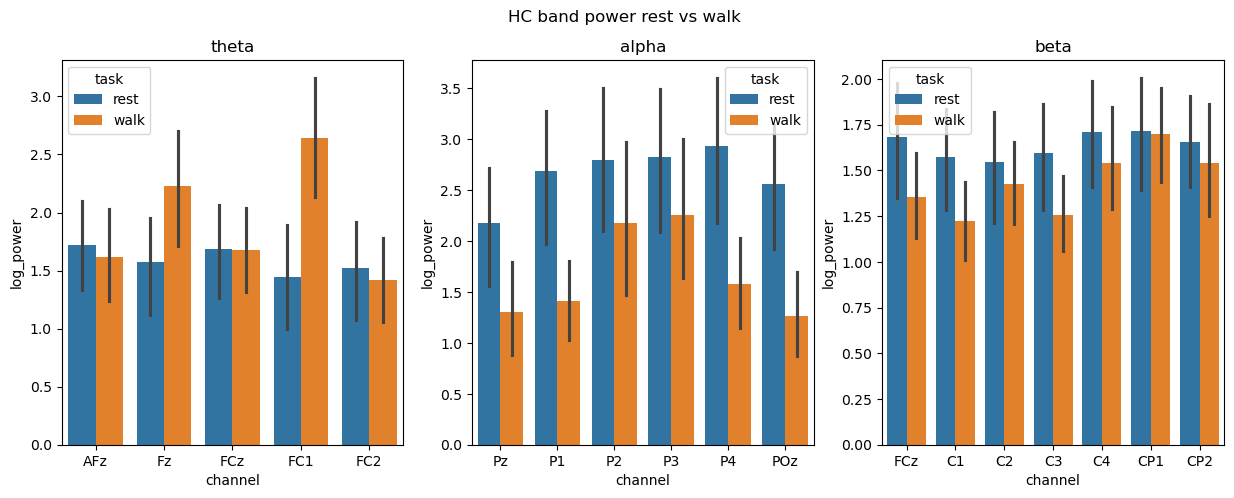

theta band power at FC1 channel is different between rest & walk of a same HC subject, **
alpha band power at Pz channel is different between rest & walk of a same HC subject, *
alpha band power at P1 channel is different between rest & walk of a same HC subject, **
alpha band power at P4 channel is different between rest & walk of a same HC subject, **
alpha band power at POz channel is different between rest & walk of a same HC subject, **
beta band power at C1 channel is different between rest & walk of a same HC subject, *
beta band power at C3 channel is different between rest & walk of a same HC subject, *


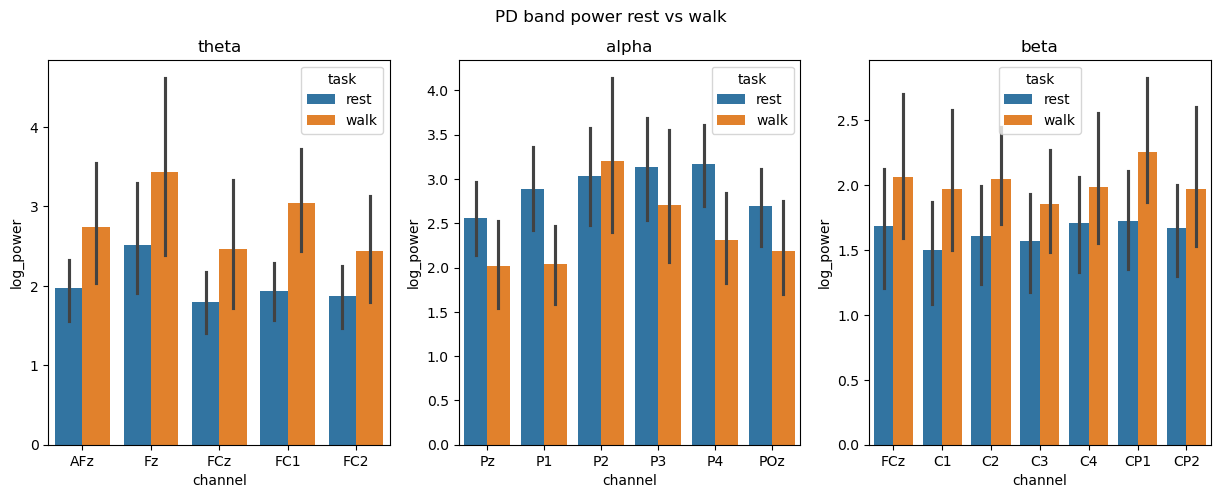

theta band power at FC1 channel is different between rest & walk of a same PD subject, *
alpha band power at P1 channel is different between rest & walk of a same PD subject, *


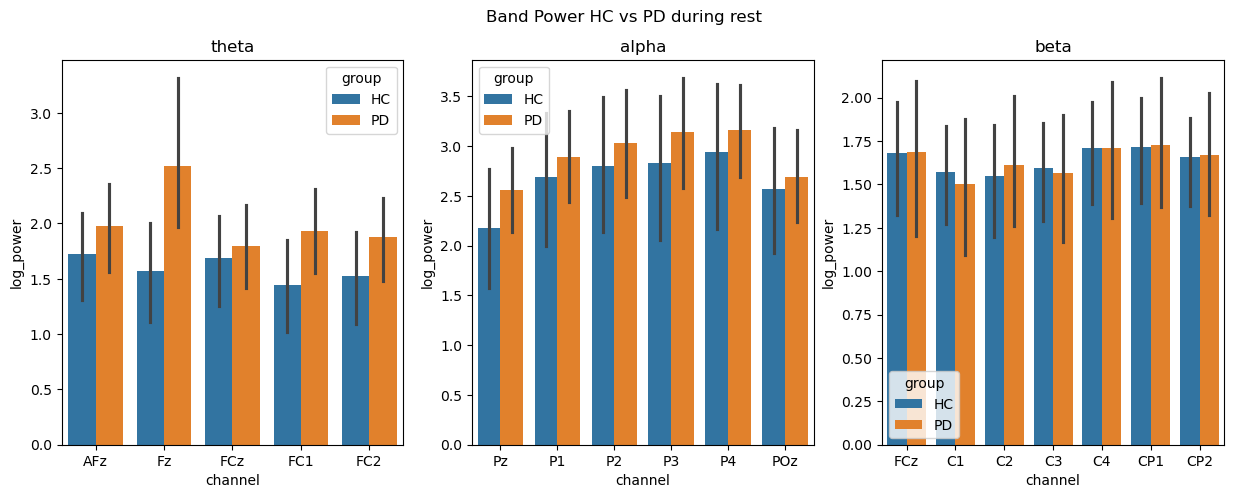

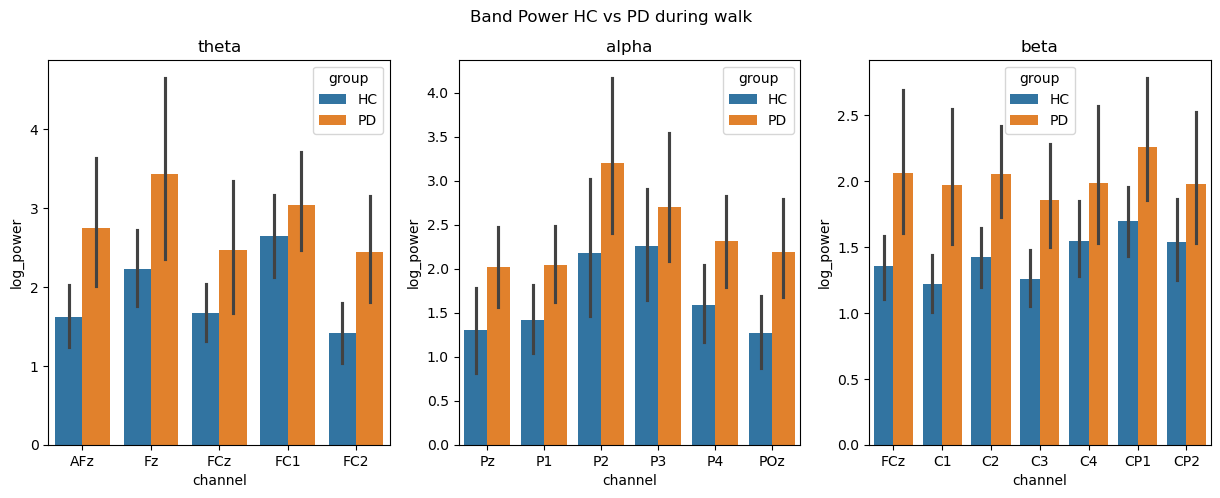

theta band power at AFz channel is different between HC & PD during walk, *
theta band power at FCz channel is different between HC & PD during walk, *
theta band power at FC2 channel is different between HC & PD during walk, *
beta band power at FCz channel is different between HC & PD during walk, *
beta band power at C1 channel is different between HC & PD during walk, *
beta band power at C2 channel is different between HC & PD during walk, *
beta band power at C3 channel is different between HC & PD during walk, *


In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, ttest_ind
from statsmodels.stats.multitest import multipletests

def pval_mark(pval):
    if pval < 0.0005:
        return '***'
    elif pval < 0.005:
        return '**'
    elif pval < 0.05:
        return '*'
    else:
        return 'n.s.'

print('p value guide: p < 0.05: *, p < 0.005: **, p < 0.0005: ***')
#Load average bandwidth of each channel
records = pd.read_csv('./avgbandpower.csv')
power_col = 'log_power' #power

# --- rest vs walk in HC or PD---
for group in ['HC','PD']:
    fig, axs = plt.subplots(1, 3, figsize = (15, 5))
    for idx, band in enumerate(['theta','alpha','beta']):
        sns.barplot(data = records.query("band == @band & group == @group"),
                    x = 'channel',
                    y = power_col,
                    hue ='task',
                    ax=axs[idx])
        axs[idx].set_title(band)
    plt.suptitle(f'{group} band power rest vs walk')
    plt.show()

    for band, ch_info in GROUP.items():
        pval_list = list()
        for ch in ch_info['channel']:
            _, pval = ttest_rel(records.query("task == 'rest' & group == @group & channel == @ch")[power_col],
                                records.query("task == 'walk' & group == @group & channel == @ch")[power_col],)
            pval_list.append(pval)
        _, pval_list, _, _ = multipletests(pval_list, method='fdr_bh')
        for idx, pval in enumerate(pval_list):
            if pval < 0.05:
                print(f"{band} band power at {ch_info['channel'][idx]} channel is different between rest & walk of a same {group} subject, {pval_mark(pval)}")

# --- HC vs PD during rest or walk---
for task in ['rest', 'walk']:
    fig, axs = plt.subplots(1, 3, figsize = (15, 5))
    for idx, band in enumerate(['theta','alpha','beta']):
        sns.barplot(data = records.query("band == @band & task == @task"),
                    x = 'channel',
                    y = power_col,
                    hue ='group',
                    ax=axs[idx])
        axs[idx].set_title(band)
    plt.suptitle(f'Band Power HC vs PD during {task}')
    plt.show()

    for band, ch_info in GROUP.items():
        pval_list = list()
        for ch in ch_info['channel']:
            _, pval = ttest_rel(records.query("group == 'HC' & task == @task & channel == @ch")[power_col],
                                records.query("group == 'PD' & task == @task & channel == @ch")[power_col],)
            pval_list.append(pval)
        _, pval_list, _, _ = multipletests(pval_list, method='fdr_bh')
        for idx, pval in enumerate(pval_list):
            if pval < 0.05:
                print(f"{band} band power at {ch_info['channel'][idx]} channel is different between HC & PD during {task}, {pval_mark(pval)}")

However, doing multiple t-tests separately can dilute real effects in one group (HC vs PD) with absent or opposite effects in the other (rest vs walk). Also, doing t-tests separately reduces data size, hence reducing statistical power. 

Instead of multiple t-tests, here we will do mixed ANOVA because it uses all data at once and directly exploits the interaction term between the diagnostic groups and the tasks.

In [41]:
df_avgband = pd.read_csv('avgbandpower.csv')
anova_results = list()
for ch_name, ch_df in df_avgband.groupby('channel'):
    band = ch_df['band'].values[0]
    aov = pg.mixed_anova(data=ch_df, dv='log_power',
                            within='task',
                            between='group',
                            subject='subject')
    anova_results.append({
            'band': band,
            'channel'      : ch_name,
            'p_group'      : aov.loc[aov.Source == 'group',             'p_unc'].values[0],
            'p_task'  : aov.loc[aov.Source == 'task',         'p_unc'].values[0],
            'p_interaction': aov.loc[aov.Source == 'Interaction', 'p_unc'].values[0],
            'F_group'      : aov.loc[aov.Source == 'group',             'F'].values[0],
            'F_task'  : aov.loc[aov.Source == 'task',         'F'].values[0],
            'F_interaction': aov.loc[aov.Source == 'Interaction', 'F'].values[0],
        })
anova_results = pd.DataFrame(anova_results).sort_values(by=['band','channel'])

# FDR correction
alpha = 0.05
for effect in ['group', 'task', 'interaction']:
    raw_col = f'p_{effect}'
    fdr_col = f'p_fdr_{effect}'
    sig_col = f'sig_{effect}'

    _, p_fdr, _, _ = multipletests(anova_results[raw_col], method='fdr_bh')
    anova_results[fdr_col] = p_fdr
    anova_results[sig_col] = p_fdr < alpha
 

In [46]:
for effect, label in [
        ('group', 'HC vs PD (overall)'),
        ('task', 'Rest vs Walk (overall)'),
        ('interaction', 'Rest → Walk differs between HC and PD'),
    ]:
    sig = anova_results[anova_results[f'sig_{effect}']]
    if sig.empty:
        print(f"\n  [{label}]")
        print(f"    No significant channels after FDR correction.")
    else:
        print(f"\n  [{label}]")
        for _, row in sig.iterrows():
            print(f"   {row['band']} {row['channel']:6s}  "
                    f"F={row[f'F_{effect}']:.2f}  "
                    f"p_fdr={row[f'p_fdr_{effect}']:.4f}")


  [HC vs PD (overall)]
    No significant channels after FDR correction.

  [Rest vs Walk (overall)]
   alpha P1      F=22.94  p_fdr=0.0002
   alpha P4      F=21.04  p_fdr=0.0003
   alpha POz     F=13.82  p_fdr=0.0029
   alpha Pz      F=12.52  p_fdr=0.0039
   theta FC1     F=29.14  p_fdr=0.0001
   theta Fz      F=10.33  p_fdr=0.0078

  [Rest → Walk differs between HC and PD]
    No significant channels after FDR correction.


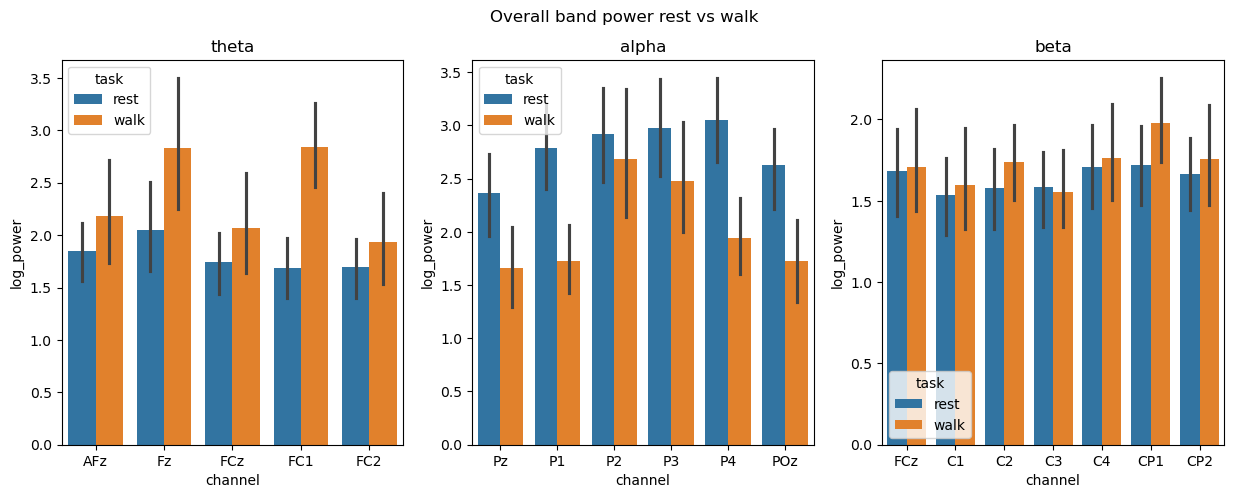

In [48]:
fig, axs = plt.subplots(1, 3, figsize = (15, 5))
for idx, band in enumerate(['theta','alpha','beta']):
    sns.barplot(data = records.query("band == @band"),
                x = 'channel',
                y = 'log_power',
                hue ='task',
                ax=axs[idx])
    axs[idx].set_title(band)
plt.suptitle(f'Overall band power rest vs walk')
plt.show()

ANOVA results suggest increased theta power on Fz and FC1 channels and suppresssed alpha power on P1, P4, POz, and Pz channels between rest and walk, regardless of diagnostic groups. However, there were no significant difference of signal power between subjects groups, and even no significant difference of brain activity from rest to walk between HC and PD.

Some brain activities will clearly change if a subject walks, because the brain has to process info like how to move limbs. However, the beta band activity on somatosensory cortex, which is known to be active during movement, remained similar even with PD. This suggest that the interrupted neural mechanism underlying gait of PD patients might not be independent regional activities. Instead, disrupted co-operations across regions might be more significant.

This naturally motivates the next analysis: studying synchronization between channels.

## Analysis 2: Cross-correlation and Synchronization between EEG channels from Opposite Hemisphere.

"Synchronization" between channels means measuring how coupled two signals are. The coupling may exist in different form: timing, frequency, or phase. To see how two channels in opposite somatosensory cortices (e.g. C1 vs C2) or fronal and central (e.g. Fz vs FCz) are synchronized and they become de-synchronized with PD, I am going to measure three different metrics.

### Cross-correlation

Cross-correlation measures **linear similarity between two signals as a function of time lag h**. The peak location tells the delay between channels, and the peak magnitude tells you the strength of coupling.

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from utils.create_preprocessed_data import load_h5
from statsmodels.graphics.tsaplots import plot_ccf
from scipy.signal import butter, sosfilt, hilbert
from config import GROUP


def bandpass(signal, band, sfreq, order=5):
    # Create the filter coefficients
    sos = butter(order, band, btype='band', fs=sfreq, output='sos')
    # Apply the filter to the data
    y = sosfilt(sos, signal)
    return y

def plot_walk_band_ccf(
                  bandname, 
                  data_HC = None,
                  data_PD = None,
                  comparisons = [('Fz','FCz'), ('C1','C2'), ('C3','C4'), ('CP1', 'CP2')]):
    if data_HC is None:
        data_HC = load_h5(f'./data_preprocessed/sub-002_walk.h5') # example HC subject
    if data_PD is None:
        data_PD = load_h5(f'./data_preprocessed/sub-047_walk.h5') # matched PD subject

    fig, axs = plt.subplots(1, len(comparisons), figsize = (23, 5))
    for idx, comparison in enumerate(comparisons):
        #if 'Fz' in comparison:
        #   bandname, band = 'alpha', (8, 12)
        #else:
        band = GROUP[bandname]['band']
        idx_1, idx_2 = np.where(np.isin(data_HC.channel, comparison))[0]

        HC1 = bandpass(signal = data_HC.values[idx_1],
                        band = band,
                        sfreq = data_HC.sfreq
                        )

        HC2 = bandpass(signal = data_HC.values[idx_2],
                        band = band,
                        sfreq = data_HC.sfreq
                        )

        PD1 = bandpass(signal = data_PD.values[idx_1],
                        band = band,
                        sfreq = data_PD.sfreq
                        )

        PD2 = bandpass(signal = data_PD.values[idx_2],
                        band = band,
                        sfreq = data_PD.sfreq
                        )
        
        plot_ccf(HC1, HC2, lags=20, ax=axs[idx], label = 'HC', use_vlines = False)
        plot_ccf(PD1, PD2, lags=20, ax=axs[idx], label = 'PD', use_vlines = False)
        axs[idx].legend()
        axs[idx].set_title(f'{comparison[0]} vs {comparison[1]} {bandname} band cross-correlation')
        axs[idx].set_xlabel('lags (s)')
        axs[idx].set_ylabel('CCF')
    plt.show()

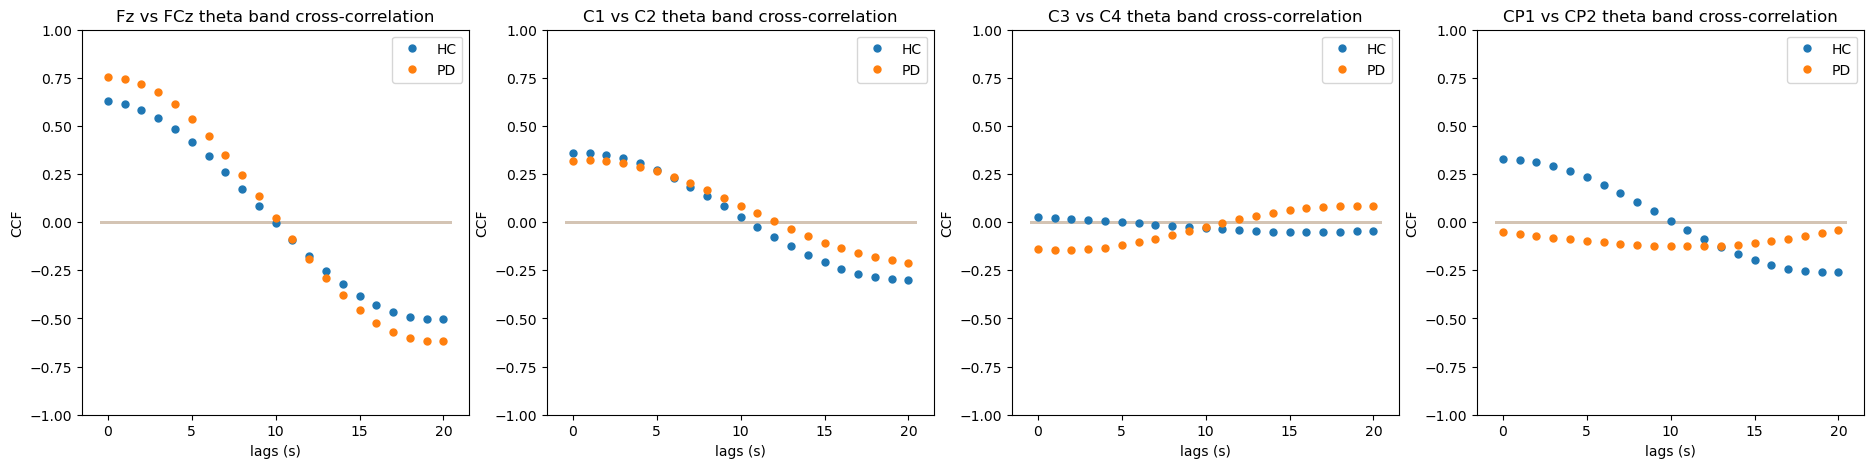

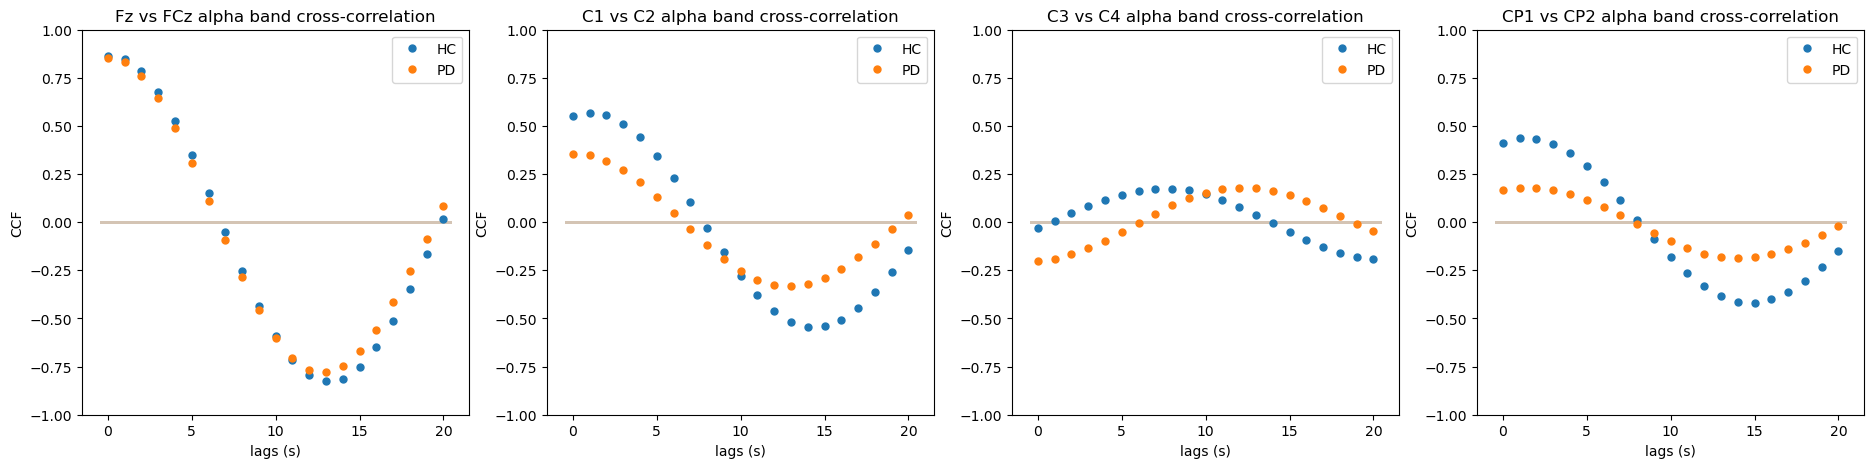

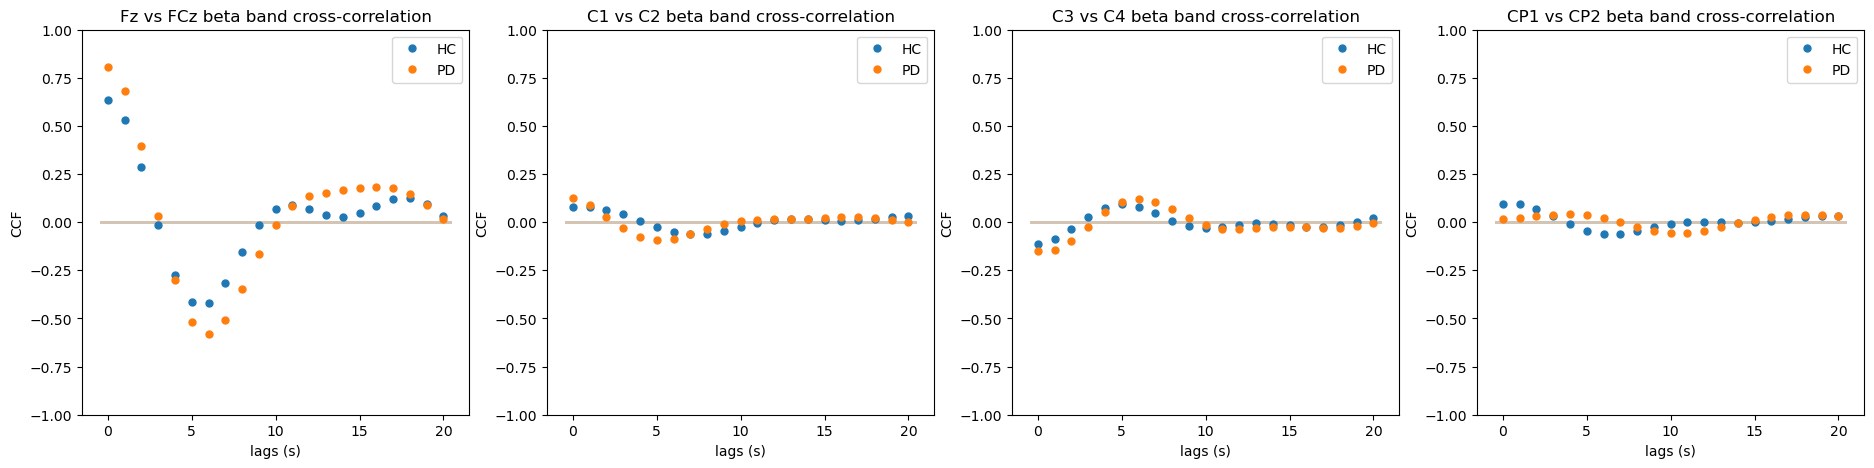

In [2]:
data_HC = load_h5(f'./data_preprocessed/sub-002_walk.h5')
data_PD = load_h5(f'./data_preprocessed/sub-047_walk.h5')
for bandname in ['theta','alpha','beta']:
    plot_walk_band_ccf(bandname = bandname,
                       data_HC=data_HC,
                       data_PD=data_PD,)

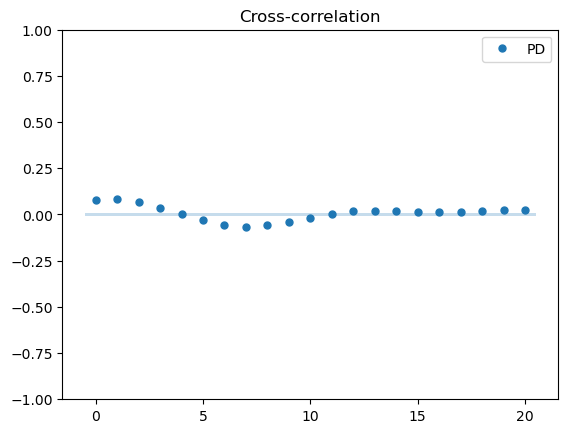

In [67]:
idx_1, idx_2 = np.where(np.isin(data_HC.channel, ('C1','C2')))[0]

PD1 = bandpass(signal = data_HC.values[idx_1],
                band = band,
                sfreq = data_HC.sfreq
                )

PD2 = bandpass(signal = data_HC.values[idx_2],
                band = band,
                sfreq = data_HC.sfreq
                )

plot_ccf(PD1, PD2, lags=20, label = 'PD', use_vlines = False)
plt.legend()
#axs[idx].set_title(f'{comparison[0]} vs {comparison[1]} {bandname} band cross-correlation')
#axs[idx].set_xlabel('lags (s)')
#axs[idx].set_ylabel('CCF')
plt.show()

In [63]:
data_HC.values[15].shape

(60903,)

In [ ]:
def cross_correlation(ch1, ch2):
    ...

### Coherence

Coherence — Frequency-Resolved Linear Coupling
The most classic measure. Ranges from 0 (no coupling) to 1 (perfect coupling) at each frequency.

In [ ]:
def coherence(ch1, ch2):
    ...

### Phase Lag Index (PLI)

In [ ]:
def PLI(ch1, ch2):
    ...